# Visium HD Colorectal Cancer Dataset

### Gene set activity quantification and pathway colocalization

This notebook demonstrates GESSO on the 10x Visium HD human colorectal cancer (CRC) tumor tissue at its native 541,968-spot resolution. We score four cell-type-specific pathways and perform a downstream pathway colocalization analysis, which examines whether tumor-associated and epithelial-associated programs co-occur at the same locations within the tumor microenvironment.

Pathways scored:

- `GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE` - intestinal epithelial program
- `BUSSLINGER_DUODENAL_IMMUNE_CELLS` - T-cell-associated immune program
- `GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN` - tumor-associated program
- `MURARO_PANCREAS_MESENCHYMAL_STROMAL_CELL` - mesenchymal stromal / fibroblast program

### Import the `gesso` package

The `gesso` Python package can be easily downloaded from source. Simply run the following script in your terminal after ensuring Python and pip are available in your environment. We recommend installing GESSO in a new Python environment.

```bash
git clone https://github.com/YMa-Lab/GESSO.git
cd GESSO
pip install .
cd ..
```

Reading Visium HD data additionally requires `scanpy` (for the 10x `.h5`) and `pyarrow` (for the tissue-positions `.parquet`):

```bash
pip install scanpy pyarrow
```

In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc

warnings.filterwarnings("ignore", message="Variable names are not unique")

project_directory = Path("__notebook__").resolve().parent.parent
sys.path.append(str(project_directory))

from gesso import GESSO

### Configure logging (optional)

In [2]:
from gesso import logging as glog

glog.enable()
glog.silence_per_geneset();

### Load the spatial transcriptomics data

In [3]:
visiumhd_root = Path(
    "/users/ayang103/data/Spatial/raw/Visium_HD/Human_CRC_FFPE/Colon_Tumor_P5/binned_outputs/square_008um"
)
expression_h5 = visiumhd_root / "filtered_feature_bc_matrix.h5"
tissue_positions_parquet = visiumhd_root / "spatial" / "tissue_positions.parquet"

pathways_csv = Path(
    "/users/ayang103/data/Project/SPLAGE/Target_Pathway_List/PathwaysTable/used_geneset"
    "/VisiumHD.CRC.PathwaysTable.0505.csv"
)
for p in (expression_h5, tissue_positions_parquet, pathways_csv):
    assert p.exists(), p

In [ ]:
t0 = time.time()
adata = sc.read_10x_h5(str(expression_h5))
adata.var_names_make_unique()
expression_df: pd.DataFrame = pd.DataFrame(
    adata.X.toarray(), index=adata.obs_names, columns=adata.var_names
)
print(f"loaded h5 in {time.time() - t0:.1f}s; shape (spots x genes) = {expression_df.shape}")
display(expression_df.iloc[:5, :8])

loaded h5 in 25.0s; shape (spots x genes) = (541968, 18085)


,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN
s_008um_00602_00290-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_008um_00789_00234-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_008um_00728_00006-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_008um_00526_00291-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_008um_00681_00396-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
locations_df = pd.read_parquet(str(tissue_positions_parquet))
locations_df = locations_df[locations_df["in_tissue"] == 1].set_index("barcode")
locations_df = locations_df.rename(columns={"array_row": "x", "array_col": "y"})[["x", "y"]]
display(locations_df.head())
print("locations shape:", locations_df.shape)

common_spots = expression_df.index.intersection(locations_df.index)
expression_df = expression_df.loc[common_spots]
locations_df = locations_df.loc[common_spots]
print("after in-tissue intersect:", expression_df.shape, locations_df.shape)

spot_total_counts = expression_df.sum(axis=1)
keep = spot_total_counts >= 50
expression_df = expression_df.loc[keep]
locations_df = locations_df.loc[keep]
print("after >=50 counts filter:", expression_df.shape, locations_df.shape)

,x,y
barcode,,
s_008um_00000_00223-1,0,223
s_008um_00000_00224-1,0,224
s_008um_00000_00225-1,0,225
s_008um_00000_00226-1,0,226
s_008um_00000_00227-1,0,227


locations shape: (541968, 2)


after in-tissue intersect: (541968, 18085) (541968, 2)


after >=50 counts filter: (460894, 18085) (460894, 2)


Load the gene set membership matrix and restrict to the four pathways. The pathway table is a $G \times n_\text{genesets}$ binary matrix.

In [ ]:
pathways = [
    "GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE",
    "BUSSLINGER_DUODENAL_IMMUNE_CELLS",
    "GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN",
    "MURARO_PANCREAS_MESENCHYMAL_STROMAL_CELL",
]

genesets_df = pd.read_csv(pathways_csv, index_col=0, usecols=["Unnamed: 0", *pathways])
genesets_df = genesets_df[pathways]
genesets_df.columns.name = None
genesets_df.index.name = None
for pw in pathways:
    print(f"{pw}: {int(genesets_df[pw].sum())} genes")
display(genesets_df.iloc[:5])

GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE: 1649 genes
BUSSLINGER_DUODENAL_IMMUNE_CELLS: 788 genes
GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN: 1670 genes
MURARO_PANCREAS_MESENCHYMAL_STROMAL_CELL: 627 genes


,GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE,BUSSLINGER_DUODENAL_IMMUNE_CELLS,GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN,MURARO_PANCREAS_MESENCHYMAL_STROMAL_CELL
SAMD11,0,0,0,0
NOC2L,0,0,0,0
KLHL17,0,0,0,0
PLEKHN1,0,0,0,0
PERM1,0,0,0,0


### Use GESSO to compute gene set activity scores

We use the `lowres` method with `n_partitions=50` (~9k spots per partition) and `stratified_kmeans` partitioning. Each of the 4 gene sets is scored across all 50 spatial partitions.

In [7]:
model = GESSO(
    expression_df=expression_df,
    locations_df=locations_df,
    genesets_df=genesets_df,
    k=20,
    normalize_counts_method="normalize-log1p",
)

start = time.time()
gas_report = model.compute_gas(
    genesets=pathways,
    beta=0.33,
    compute_method="lowres",
    partition_method="stratified_kmeans",
    n_partitions=50,
    n_jobs=40,
    store_gene_contributions=True,
)
print(f"compute_gas done in {time.time() - start:.1f} s for {len(pathways)} gene sets")

gas_df = gas_report.gas_df()
display(gas_df.head())

GESSO (info): Removed 3 genes not found in geneset data. 18032 genes remain. 


GESSO (info): Removed 53 genes not found in expression data. 18032 genes remain. 


GESSO (info): Identified 18032 common genes in the gene set and expression data. 


GESSO (info): Identified 460894 common spots in the location and expression data. 


GESSO (info): Normalized expression data with strategy 'normalize-log1p'. 


GESSO (info): Model initialization complete. 


GESSO (info): Beginning low resolution activity score computation for 4 gene sets with 4 
               jobs. Method used: lowres. 


compute_gas done in 8864.0 s for 4 gene sets


,GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE,BUSSLINGER_DUODENAL_IMMUNE_CELLS,GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN,MURARO_PANCREAS_MESENCHYMAL_STROMAL_CELL
s_008um_00602_00290-1,-2.952496,-0.527955,-2.119333,3.403775
s_008um_00789_00234-1,-3.144627,-0.996569,-1.649031,3.866180
s_008um_00728_00006-1,-2.745910,3.940566,-1.357936,5.941730
s_008um_00526_00291-1,0.331325,-2.654313,-2.657874,-2.478389
s_008um_00681_00396-1,-3.018818,-1.262808,-1.380834,-0.599498


Top gene contributions per pathway

In [8]:
for pw in pathways:
    top = gas_report.gene_contributions_df(geneset=pw).head(8)
    print(f"\n=== top contributors: {pw} ===")
    print(top)


=== top contributors: GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE ===
         GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE
CEACAM5                                     0.212709
PIGR                                        0.208471
TSPAN8                                      0.196533
MUC12                                       0.188096
SLC26A3                                     0.153996
TSPAN1                                      0.152763
CD24                                        0.137660
FXYD3                                       0.137645

=== top contributors: BUSSLINGER_DUODENAL_IMMUNE_CELLS ===
        BUSSLINGER_DUODENAL_IMMUNE_CELLS
CXCR4                           0.145287
VIM                             0.142737
SRGN                            0.135416
IL7R                            0.120010
CD52                            0.114583
LAPTM5                          0.112728
CCL5                            0.111202
IKZF1                           0.111154

=== top contributors: 

### Visualize spatial maps for the four pathways

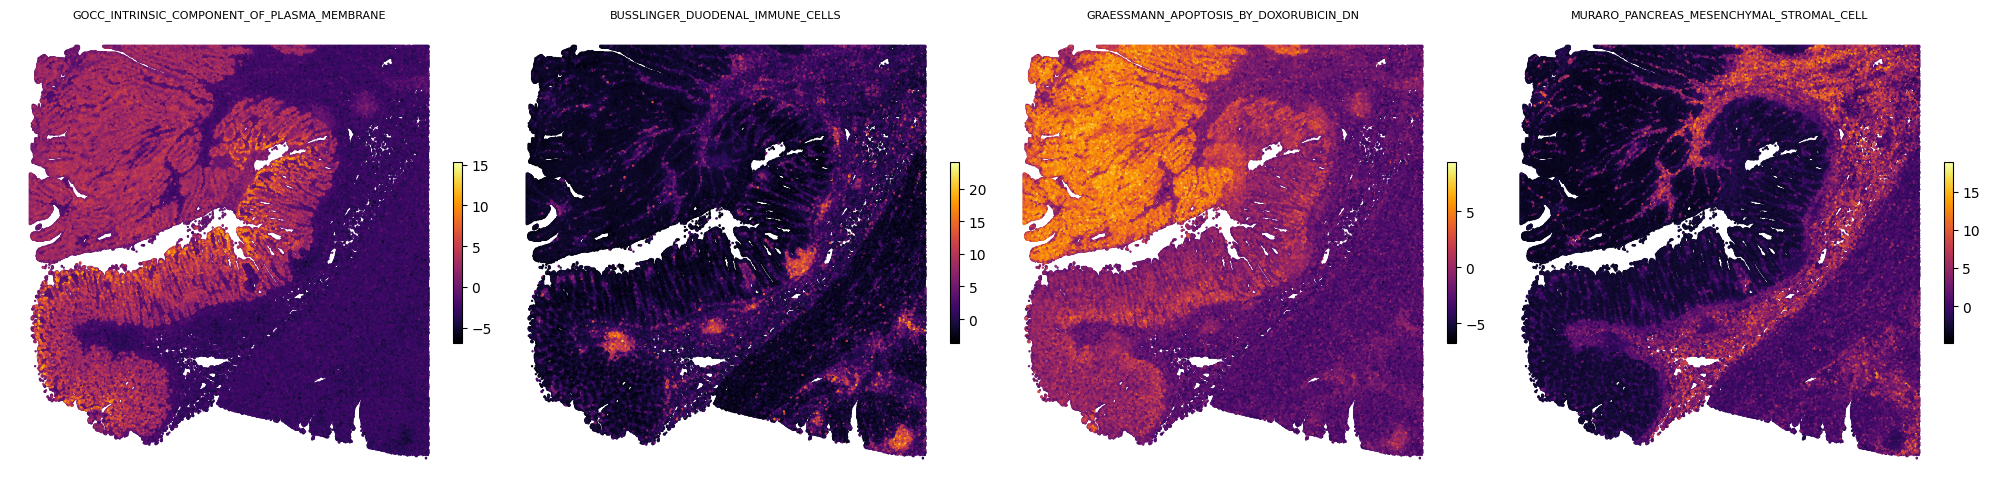

In [9]:
fig, axes = plt.subplots(1, len(pathways), figsize=(5 * len(pathways), 5))
for ax, pw in zip(axes, pathways):
    gas_report.plot_gas_spatial_map(
        geneset=pw, size=0.5, cmap="inferno", figsize=(5, 5), ax=ax,
    )
    ax.set_title(pw, fontsize=8)
    ax.invert_yaxis()
fig.tight_layout()
display(fig)
plt.close(fig)

### Downstream: pathway colocalization in the tumor microenvironment

Distinct pathway programs colocalize within tumor niches: pairs of pathways drawn from a tumor-associated module and an epithelial-associated module exhibit increased spatial correlation in tumor tissue. Here we visualize a single representative pair: the tumor-associated pathway `GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN` and the epithelial-associated pathway `GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE`.

We first quantify their global colocalization with Pearson's $r$ across spots, then render a bivariate spatial map. Each spot is classified into one of four categories based on whether its GAS for each pathway is above or below the within-pathway median (median split per pathway): low/low, tumor-only, epithelial-only, both-high. Spots in the both-high category are the regions where the two programs colocalize.

In [10]:
tumor_pw = "GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN"
epi_pw = "GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE"

tumor_gas = gas_df[tumor_pw]
epi_gas = gas_df[epi_pw]

pearson_r = tumor_gas.corr(epi_gas)
print(f"Pearson r({tumor_pw}, {epi_pw}) = {pearson_r:.3f}")

Pearson r(GRAESSMANN_APOPTOSIS_BY_DOXORUBICIN_DN, GOCC_INTRINSIC_COMPONENT_OF_PLASMA_MEMBRANE) = 0.671


fraction of spots in 'colocalized' (both-high) category: 0.424


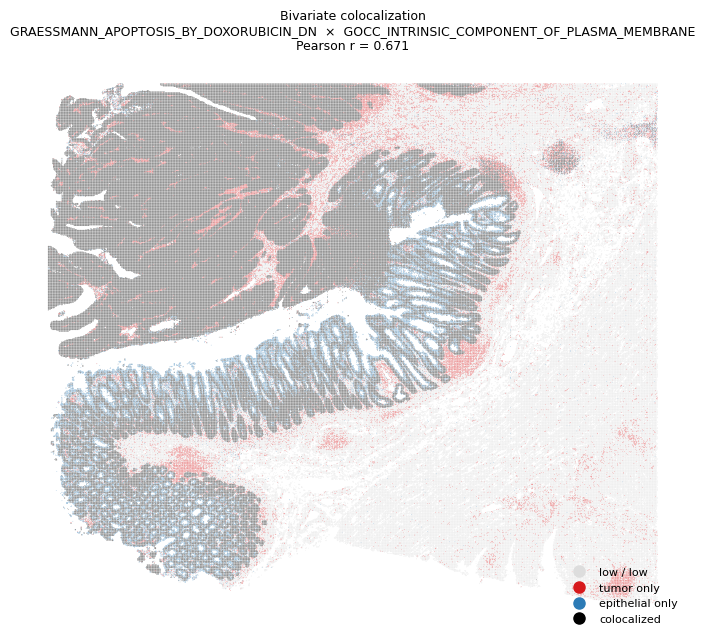

In [ ]:
tumor_high = (tumor_gas > tumor_gas.median()).astype(int)
epi_high = (epi_gas > epi_gas.median()).astype(int)
biv_class = (2 * epi_high + tumor_high).rename("biv_class")

biv_palette = {
    0: "#dddddd",  # low/low: grey
    1: "#d7191c",  # tumor only: red
    2: "#2c7bb6",  # epithelial only: blue
    3: "#000000",  # colocalized: black
}
biv_labels = {
    0: "low / low",
    1: "tumor only",
    2: "epithelial only",
    3: "colocalized",
}

frac_coloc = (biv_class == 3).mean()
print(f"fraction of spots in 'colocalized' (both-high) category: {frac_coloc:.3f}")

plot_df = locations_df.copy()
plot_df["biv_class"] = biv_class
plot_df["color"] = plot_df["biv_class"].map(biv_palette)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    plot_df["x"], plot_df["y"],
    c=plot_df["color"], s=0.5, marker=".", linewidths=0,
)
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(
    f"Bivariate colocalization\n{tumor_pw}  \u00d7  {epi_pw}\nPearson r = {pearson_r:.3f}",
    fontsize=9,
)
handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=biv_palette[i], label=biv_labels[i], markersize=8)
           for i in [0, 1, 2, 3]]
ax.legend(handles=handles, loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
display(fig)
plt.close(fig)

Black regions in the bivariate map correspond to spots where both the tumor-associated and epithelial-associated pathways are co-elevated. These colocalized regions concentrate within the tumor compartment and can be interpreted as coordinated tumor-epithelial cross-talk emerging during tumor progression. The same procedure can be applied to any other pathway pair drawn from the GAS table.